In [1]:
%pip install langgraph

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os

load_dotenv()

model = ChatGoogleGenerativeAI(
    model=os.getenv("GEMINI_MODEL", "gemini-2.0-flash"),
    google_api_key=os.getenv("GEMINI_API_FREE_KEY") or os.getenv("GEMINI_API_KEY")
)

model.invoke('안녕하세요!')

AIMessage(content=[{'type': 'text', 'text': '안녕하세요! 반갑습니다. 무엇을 도와드릴까요? 궁금한 점이 있거나 도움이 필요하시면 언제든 말씀해 주세요.', 'extras': {'signature': 'EqQFCqEFAb4+9vsskkUuVowlv5oJA8lCT/t4UGiVvRrNZd/STP+MVVfMLBVV2vq+528BU3Or/If9IxtFDTUmLBAkeeywhzLohdEJHv71R814JA49iLhx1EAnm9NKG5w+cZpl9yLbOe4isre65Axb5jvGVw5Jr7D02eT3y7gzX2k3a22LTateFRGoGkDUMhHhQ6Wa+BtWCvkXN6fEX5AaiZPptwSHBvmP5YukzRhpI4d8iYBt8fnsM8PI82y7hHkdHFVmg1DKGfZnTR34UyvN8KOMYyYDmt532LtMYJtVtSxO8rO6dbHcJ6OTSiZErzSNxPpt9Q/SjHtxqLJ+57Y0fsqzRlfCS9X+l2pppP9rz6lEteHidKEJdboIkjJK+4C11HQBVzfzSO6GDBjFHNikEEtnX8YVUxxKbN48mQjrOYzKofiM1ybuPvgj7QGpQJoX9yxg3qi9EZ9W28i7bJY8/hFTPj3Td2e65FfdnjeUL2rjA1/XNdoxa2HaUs/2TPoKc7d64arFZMfIYHuTD1UdH4mQja7GkASkv4SKCOK7nf4pb7eWLv+oyx97jIRuNhRjorYB+fAO9FuYroVm/EQ47hsCBgIDe1aR3jEuWM/Tb0s3CAJc82MnDoRGZ6eWB+wZTDtUX+UOexjISbDeV4KE3CmuWx7whwfs+l2c+RCfvv58WjLglffry1ECfYDHUx+waLleQ5iUYt4URTvZgeg3qSYwnauYloESJU6KOipnqf4bG1pHXcPXa45+Quh/AuU02I4liiVT2Eyq/4F1b9sBsL8O9eHpe14qkNDLMOjwLvJYr8gaWarm7/xzQ3uSs+0tP9eY7pmQbAI87yqeBxEQqBn7MQYrJy3w7Z4L

In [3]:
from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):	#①
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.   #②
       'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.  #③
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]	#②

# StateGraph 클래스를 사용하여 State 타입의 그래프를 생성합니다.
graph_builder = StateGraph(State) #④

In [4]:
def generate(state: State):	#①
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.
		
    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리. 
          형식은 {"messages": [응답 메시지]}입니다.
    """ 
    return {"messages": [model.invoke(state["messages"])]}	#②

graph_builder.add_node("generate", generate)	#③

In [5]:
graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)    

graph = graph_builder.compile()

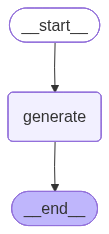

In [6]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception: 
    pass

In [7]:
response = graph.invoke({"messages": ["안녕하세요! 저는 이성용입니다"]})

print(type(response))
response

<class 'dict'>


{'messages': [HumanMessage(content='안녕하세요! 저는 이성용입니다', additional_kwargs={}, response_metadata={}, id='145a161f-04ff-410d-b712-f476636de781'),
  AIMessage(content=[{'type': 'text', 'text': '안녕하세요, 이성용님! 만나서 반갑습니다. 😊\n\n무엇을 도와드릴까요? 궁금한 점이 있으시거나 도움이 필요하시면 언제든 편하게 말씀해 주세요!', 'extras': {'signature': 'EuoMCucMAb4+9vue5veaIThKlv8kvJxYtPl7pHyJC6vP2432pE0qynE+CHaIKzHSlDF2T8jkWIhve+gy6idmlrXtx9aTjUhpo5CBFkaFGtKg5iZSfS15Mkm7QYdvxHmJp1PXKdKq4JctRxO2liOFdcnIDFk0ytT44unn6z3qtsNMtFq+ofpVj5vltt9ZyIkvIQvVdQV3jz7c+n5qawaSxK6Qokk54JcA3EojghegOlegwjGpdHPRxD3jfukult/PO6kk6Pvi5Jhdv6/wrBQruNaakZpFtP6y/MN2FYU+mkEeiR55JCSkUc8hB5shEZ5GWkj0/334z3J4UvbssRY9Dy8u/dlAhra7V6WKNjZRrFhPFiIXr5hi+jeTcXPTC4NBQAwhkfWbZGc76bFu0H1Q2X+hcQAsHtlnIPyzo8VoxTW7EyPTg9XSfzXmDEVQewm+3rJ0JnYWFksu3BgRS5oQOkcGjpSApn4MDEi3fftO2A4PhDLXXFmONJsk3T7od2jZnk8CAVLqxLacaTkZNf6nE9TUUb0LT7J0pXCu/ZjYGGhUk/utmPCZUP+pFSn/wMqAvc1zqoVwKl9zUjOIQAQfuuT9KRpnhuSqkEEufp8FL2VtbpsfDXC859ug01RzitoJieT9S5odizXkp0Msfbq4J+gd9ym2xtERnVtI43fZLBQx0DgKLsLb0U9YSL56Pp

In [8]:
response["messages"].append("제 이름을 아시나요?")
graph.invoke(response)

{'messages': [HumanMessage(content='안녕하세요! 저는 이성용입니다', additional_kwargs={}, response_metadata={}, id='145a161f-04ff-410d-b712-f476636de781'),
  AIMessage(content=[{'type': 'text', 'text': '안녕하세요, 이성용님! 만나서 반갑습니다. 😊\n\n무엇을 도와드릴까요? 궁금한 점이 있으시거나 도움이 필요하시면 언제든 편하게 말씀해 주세요!', 'extras': {'signature': 'EuoMCucMAb4+9vue5veaIThKlv8kvJxYtPl7pHyJC6vP2432pE0qynE+CHaIKzHSlDF2T8jkWIhve+gy6idmlrXtx9aTjUhpo5CBFkaFGtKg5iZSfS15Mkm7QYdvxHmJp1PXKdKq4JctRxO2liOFdcnIDFk0ytT44unn6z3qtsNMtFq+ofpVj5vltt9ZyIkvIQvVdQV3jz7c+n5qawaSxK6Qokk54JcA3EojghegOlegwjGpdHPRxD3jfukult/PO6kk6Pvi5Jhdv6/wrBQruNaakZpFtP6y/MN2FYU+mkEeiR55JCSkUc8hB5shEZ5GWkj0/334z3J4UvbssRY9Dy8u/dlAhra7V6WKNjZRrFhPFiIXr5hi+jeTcXPTC4NBQAwhkfWbZGc76bFu0H1Q2X+hcQAsHtlnIPyzo8VoxTW7EyPTg9XSfzXmDEVQewm+3rJ0JnYWFksu3BgRS5oQOkcGjpSApn4MDEi3fftO2A4PhDLXXFmONJsk3T7od2jZnk8CAVLqxLacaTkZNf6nE9TUUb0LT7J0pXCu/ZjYGGhUk/utmPCZUP+pFSn/wMqAvc1zqoVwKl9zUjOIQAQfuuT9KRpnhuSqkEEufp8FL2VtbpsfDXC859ug01RzitoJieT9S5odizXkp0Msfbq4J+gd9ym2xtERnVtI43fZLBQx0DgKLsLb0U9YSL56Pp

In [11]:
inputs = {"messages": [("human", "한국과 일본의 관계에 대해 자세히 알려줘")]}
for chunk, _ in graph.stream(inputs, stream_mode="messages"):
    content = chunk.content
    if isinstance(content, list) and len(content) > 0:
        text = content[0].get("text", "")
        if text:
            print(text, end="")
    elif isinstance(content, str) and content:
        print(content, end="")

한국과 일본의 관계는 **'가깝고도 먼 나라'**라는 말로 요약될 정도로 매우 복합적이고 다층적입니다. 양국은 지리적으로 인접해 있고 민주주의와 시장경제라는 가치를 공유하며 경제적·문화적으로 밀접하게 연결되어 있지만, 과거사 문제로 인한 갈등이 수시로 분출되는 특수한 관계에 있습니다.

주요 내용을 몇 가지 핵심 카테고리로 나누어 자세히 설명해 드리겠습니다.

---

### 1. 역사적 배경과 갈등의 기원
한일 관계의 가장 큰 갈등의 뿌리는 **1910년부터 1945년까지 이어진 일제의 식민 지배**에 있습니다.

*   **1965년 한일기본조약:** 양국은 1965년 국교를 정상화하며 경제 협력 자금을 주고받았으나, 이때 '개인 청구권'이 완전히 소멸되었는지에 대한 해석 차이가 오늘날까지 갈등의 불씨가 되고 있습니다.
*   **일본군 '위안부' 문제:** 전시 성폭력 피해에 대한 일본 정부의 진정성 있는 사과와 법적 책임을 둘러싼 갈등입니다. 2015년 합의가 있었으나 피해자들의 동의 부족으로 논란이 지속되었습니다.
*   **강제동원 피해자 배상:** 최근 몇 년간 가장 뜨거웠던 쟁점입니다. 2018년 한국 대법원이 일본 기업의 배상 책임을 인정하는 판결을 내리자, 일본은 이에 반발하며 수출 규제 조치를 단행했고 양국 관계는 최악으로 치달았습니다.

### 2. 영토 분쟁 (독도)
*   독도는 역사적, 지리적, 국제법적으로 명백한 대한민국의 영토이며 한국이 실효적으로 지배하고 있습니다.
*   그러나 일본은 지속적으로 독도(다케시마)에 대한 영유권을 주장하며 교과서 검정, 외교청서 등을 통해 도발하고 있어 한국 내 반일 감정을 자극하는 주요 원인이 됩니다.

### 3. 경제 및 문화적 교류 (정경분리)
정치적 갈등과는 별개로 경제와 문화는 매우 밀접하게 얽혀 있습니다.

*   **경제적 상호의존:** 양국은 중요한 무역 파트너입니다. 반도체 소재·부품·장비 등 공급망에서 긴밀히 연결되어 있습니다.
*   **문화 교류 (한류와 일류):** 
  